# Create SCE of viscello EHT data
paper: https://ashpublications.org/blood/article/136/7/845/455111/Developmental-trajectory-of-prehematopoietic-stem <br>
data: https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE137116

In [30]:
suppressPackageStartupMessages({
    library(data.table)
    library(SingleCellExperiment)
    library(tidyr)
    library(stringr)
    library(purrr)
    library(Matrix)
    library(ggplot2)
    library(ggpubr)
})

In [2]:
dir = '/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/tan/'

In [9]:
counts = readMM(file.path(dir, 'original/GSE137116_gene_by_cell_count_matrix.txt.gz'))

In [13]:
meta = fread(file.path(dir, 'original/GSE137116_cell_annotation.csv.gz')) %>% setnames('V1', 'cell')
genes = fread(file.path(dir, 'original/GSE137116_gene_annotation.csv.gz'))

In [14]:
head(meta)
head(genes)

cell,Total_mRNAs,num_genes_expressed,Size_Factor,Dataset,Combined_Dataset,MitoFraction,Cell_type,Cell_type_refined,pseudotime_slingshot,arterial_score,venous_score,Cell_cycle_phase
<chr>,<int>,<int>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>
AAACCTGGTGCTCTTC-1-2,4134,1509,0.3093109,E10.5_E_01,E10.5 E,0.04958878,Endo (Wnt_low),Endo (Wnt_low) [VE],4.728201,-0.03498555,0.06061348,S
AAACCTGTCAACGAAA-1-2,14457,3333,1.0816903,E10.5_E_01,E10.5 E,0.01992115,Endo (other),Endo (other),1.633389,0.01240980,0.28844700,G1
AAACGGGAGGAGCGAG-1-2,5394,1646,0.4035856,E10.5_E_01,E10.5 E,0.02020764,Endo (low quality),Endo (low quality),NA,0.20246873,-0.42089932,NA
AAACGGGGTAAACCTC-1-2,5282,1570,0.3952057,E10.5_E_01,E10.5 E,0.04449072,Endo (low quality),Endo (low quality),NA,-0.08234319,0.05297983,NA
AAAGATGGTGATGTCT-1-2,3615,1177,0.2704787,E10.5_E_01,E10.5 E,0.06832642,Endo (low quality),Endo (low quality),NA,0.07320080,0.13550054,NA
AAAGTAGAGTAAGTAC-1-2,2417,1305,0.1808429,E10.5_E_01,E10.5 E,0.07116260,Endo (Wnt_low),Endo (Wnt_low) [VE],4.813140,0.16527767,0.70419455,G1


id,symbol
<chr>,<chr>
ENSMUSG00000051951,Xkr4
ENSMUSG00000089699,Gm1992
ENSMUSG00000102343,Gm37381
ENSMUSG00000025900,Rp1
ENSMUSG00000109048,Rp1
ENSMUSG00000025902,Sox17


In [15]:
rownames(counts) = genes$symbol
colnames(counts) = meta$cell

In [16]:
head(counts)

   [[ suppressing 34 column names ‘AAACCTGGTGCTCTTC-1-2’, ‘AAACCTGTCAACGAAA-1-2’, ‘AAACGGGAGGAGCGAG-1-2’ ... ]]



6 x 46048 sparse Matrix of class "dgTMatrix"
                                                                           
Xkr4    . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .
Gm1992  . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .
Gm37381 . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .
Rp1     . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .
Rp1     . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .
Sox17   . 2 . . 2 1 6 . 1 1 3 . . 2 . . 1 . . 2 . . 1 2 3 . . 1 2 . . . 1 1
              
Xkr4    ......
Gm1992  ......
Gm37381 ......
Rp1     ......
Rp1     ......
Sox17   ......

 .....suppressing 46014 columns in show(); maybe adjust 'options(max.print= *, width = *)'
 ..............................

In [18]:
sce <- SingleCellExperiment(list(counts=counts))
sce

class: SingleCellExperiment 
dim: 27998 46048 
metadata(0):
assays(1): counts
rownames(27998): Xkr4 Gm1992 ... Vmn2r122 CAAA01147332.1
rowData names(0):
colnames(46048): AAACCTGGTGCTCTTC-1-2 AAACCTGTCAACGAAA-1-2 ...
  TTTGTCAGTTAAGTAG-1-b TTTGTCATCGCCAGCA-1-b
colData names(0):
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):

In [19]:
colData(sce) = meta %>% 
                as.data.frame %>% 
                tibble::column_to_rownames("cell") %>%
                .[colnames(sce),] %>% DataFrame()

In [22]:
head(meta)

cell,Total_mRNAs,num_genes_expressed,Size_Factor,Dataset,Combined_Dataset,MitoFraction,Cell_type,Cell_type_refined,pseudotime_slingshot,arterial_score,venous_score,Cell_cycle_phase
<chr>,<int>,<int>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>
AAACCTGGTGCTCTTC-1-2,4134,1509,0.3093109,E10.5_E_01,E10.5 E,0.04958878,Endo (Wnt_low),Endo (Wnt_low) [VE],4.728201,-0.03498555,0.06061348,S
AAACCTGTCAACGAAA-1-2,14457,3333,1.0816903,E10.5_E_01,E10.5 E,0.01992115,Endo (other),Endo (other),1.633389,0.01240980,0.28844700,G1
AAACGGGAGGAGCGAG-1-2,5394,1646,0.4035856,E10.5_E_01,E10.5 E,0.02020764,Endo (low quality),Endo (low quality),NA,0.20246873,-0.42089932,NA
AAACGGGGTAAACCTC-1-2,5282,1570,0.3952057,E10.5_E_01,E10.5 E,0.04449072,Endo (low quality),Endo (low quality),NA,-0.08234319,0.05297983,NA
AAAGATGGTGATGTCT-1-2,3615,1177,0.2704787,E10.5_E_01,E10.5 E,0.06832642,Endo (low quality),Endo (low quality),NA,0.07320080,0.13550054,NA
AAAGTAGAGTAAGTAC-1-2,2417,1305,0.1808429,E10.5_E_01,E10.5 E,0.07116260,Endo (Wnt_low),Endo (Wnt_low) [VE],4.813140,0.16527767,0.70419455,G1


In [34]:
p1 = ggplot(meta, aes(Dataset, Total_mRNAs, fill=Dataset)) + geom_boxplot() + theme_bw() + theme(legend.position='none', axis.text.x=element_text(angle=-90, hjust=0, vjust=0))
p2 = ggplot(meta, aes(Dataset, num_genes_expressed, fill=Dataset)) + geom_boxplot() + theme_bw() + theme(legend.position='none', axis.text.x=element_text(angle=-90, hjust=0, vjust=0))
p3 = ggplot(meta, aes(Dataset, MitoFraction, fill=Dataset)) + geom_boxplot() + theme_bw() + theme(legend.position='none', axis.text.x=element_text(angle=-90, hjust=0, vjust=0))

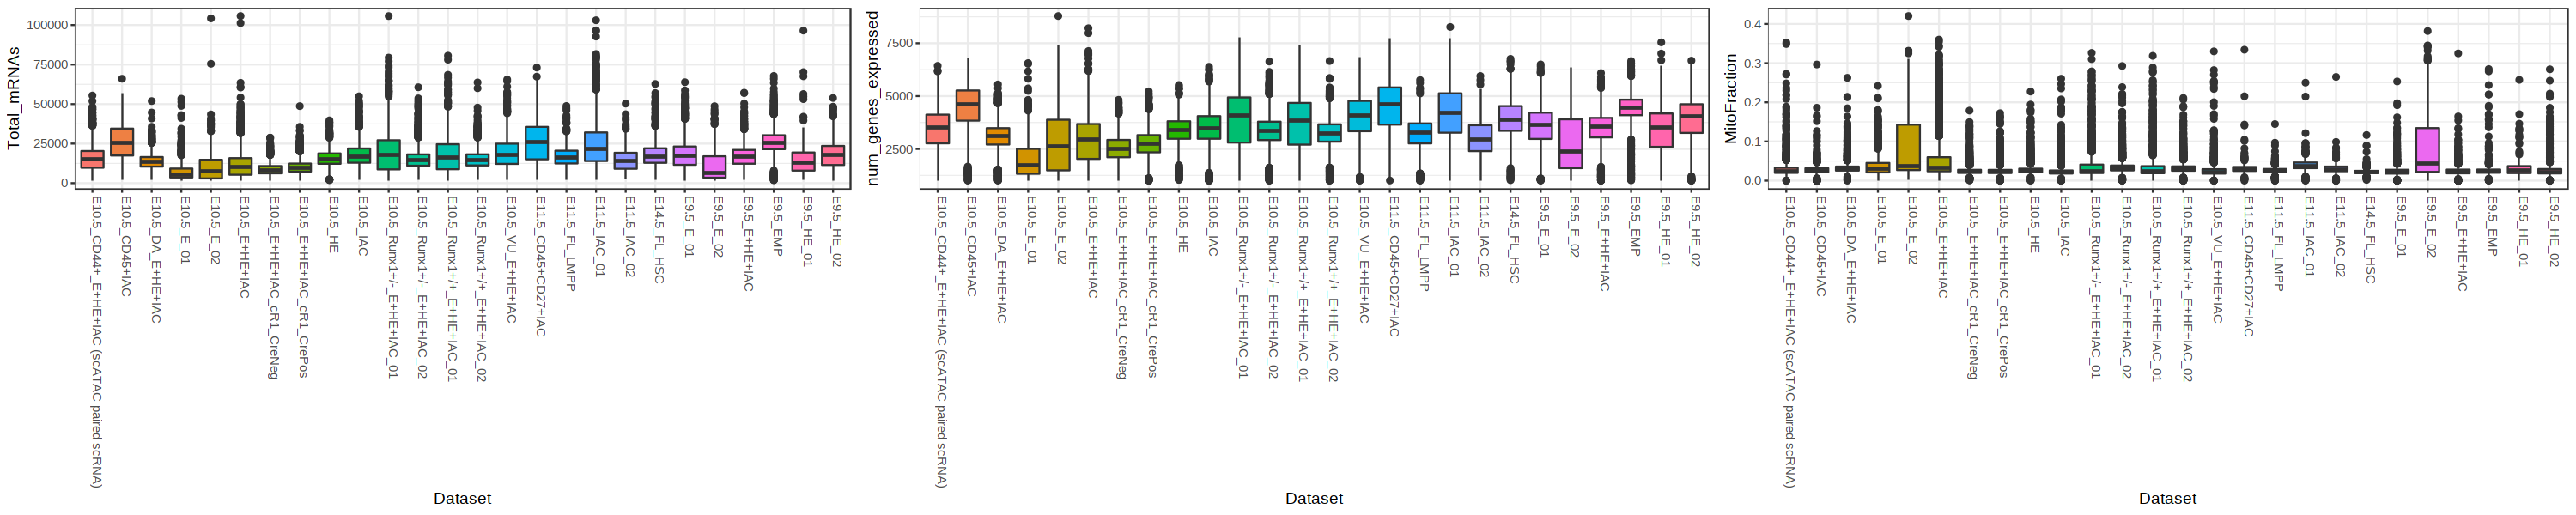

In [35]:
options(repr.plot.width=25, repr.plot.height=5) 

ggarrange(plotlist=list(p1,p2,p3), ncol=3)

In [36]:
# basic QC based on mitochondrial fraction
meta = meta[MitoFraction<=0.1]

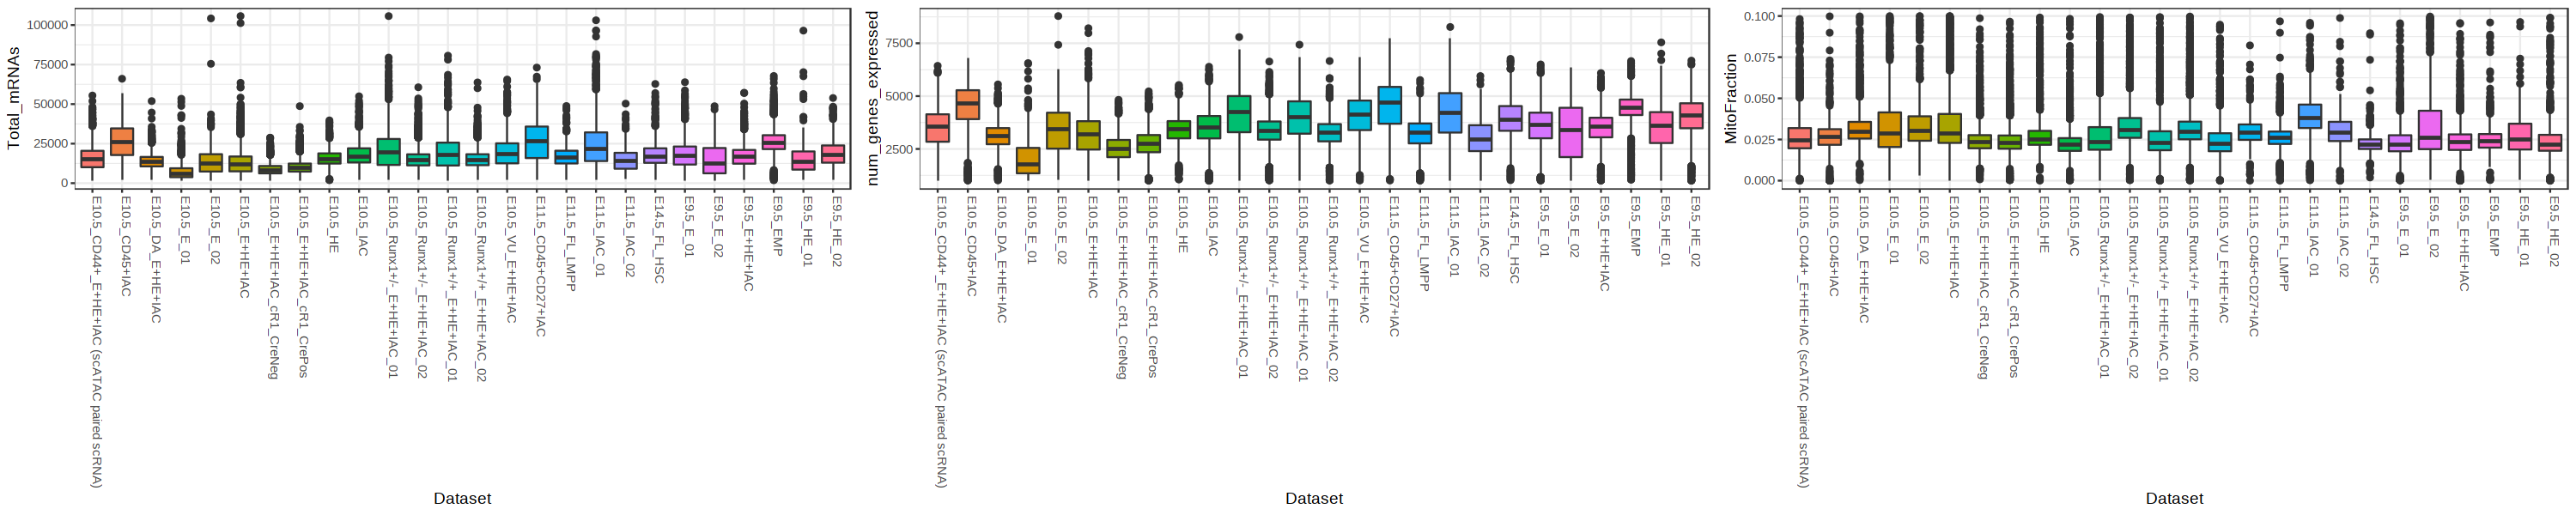

In [37]:
p1 = ggplot(meta, aes(Dataset, Total_mRNAs, fill=Dataset)) + geom_boxplot() + theme_bw() + theme(legend.position='none', axis.text.x=element_text(angle=-90, hjust=0, vjust=0))
p2 = ggplot(meta, aes(Dataset, num_genes_expressed, fill=Dataset)) + geom_boxplot() + theme_bw() + theme(legend.position='none', axis.text.x=element_text(angle=-90, hjust=0, vjust=0))
p3 = ggplot(meta, aes(Dataset, MitoFraction, fill=Dataset)) + geom_boxplot() + theme_bw() + theme(legend.position='none', axis.text.x=element_text(angle=-90, hjust=0, vjust=0))
ggarrange(plotlist=list(p1,p2,p3), ncol=3)

In [38]:
sce = sce[,meta$cell]

In [39]:
sce

class: SingleCellExperiment 
dim: 27998 44060 
metadata(0):
assays(1): counts
rownames(27998): Xkr4 Gm1992 ... Vmn2r122 CAAA01147332.1
rowData names(0):
colnames(44060): AAACCTGGTGCTCTTC-1-2 AAACCTGTCAACGAAA-1-2 ...
  TTTGTCAGTTAAGTAG-1-b TTTGTCATCGCCAGCA-1-b
colData names(12): Total_mRNAs num_genes_expressed ... venous_score
  Cell_cycle_phase
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):

In [43]:
head(meta)

cell,Total_mRNAs,num_genes_expressed,Size_Factor,Dataset,Combined_Dataset,MitoFraction,Cell_type,Cell_type_refined,pseudotime_slingshot,arterial_score,venous_score,Cell_cycle_phase
<chr>,<int>,<int>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>
AAACCTGGTGCTCTTC-1-2,4134,1509,0.3093109,E10.5_E_01,E10.5 E,0.04958878,Endo (Wnt_low),Endo (Wnt_low) [VE],4.728201,-0.03498555,0.06061348,S
AAACCTGTCAACGAAA-1-2,14457,3333,1.0816903,E10.5_E_01,E10.5 E,0.01992115,Endo (other),Endo (other),1.633389,0.01240980,0.28844700,G1
AAACGGGAGGAGCGAG-1-2,5394,1646,0.4035856,E10.5_E_01,E10.5 E,0.02020764,Endo (low quality),Endo (low quality),NA,0.20246873,-0.42089932,NA
AAACGGGGTAAACCTC-1-2,5282,1570,0.3952057,E10.5_E_01,E10.5 E,0.04449072,Endo (low quality),Endo (low quality),NA,-0.08234319,0.05297983,NA
AAAGATGGTGATGTCT-1-2,3615,1177,0.2704787,E10.5_E_01,E10.5 E,0.06832642,Endo (low quality),Endo (low quality),NA,0.07320080,0.13550054,NA
AAAGTAGAGTAAGTAC-1-2,2417,1305,0.1808429,E10.5_E_01,E10.5 E,0.07116260,Endo (Wnt_low),Endo (Wnt_low) [VE],4.813140,0.16527767,0.70419455,G1


In [44]:
meta = meta[,stage:=str_split(Dataset, '_') %>% map_chr(1)]

In [46]:
fwrite(meta, file.path(dir, 'processed/meta.txt.gz'))

In [41]:
fwrite(genes, file.path(dir, 'processed/genes.txt.gz'))

In [42]:
saveRDS(sce, file.path(dir, 'processed/sce.rds'))